# **Predictive Modeling of Building Energy Efficiency**
**Author:** Robert Gravatt  
**Course:** DATA 201 - Statistical Methods in Data Science  
**Date:** April 29, 2026  

---

## **1. Introduction**
In the field of sustainable architecture, the ability to predict the energy requirements of a building during the design phase is crucial for reducing environmental impact and operational costs. This project utilizes a dataset of simulated building configurations to analyze the thermal performance of residential structures. By examining various architectural features, we aim to understand the drivers of energy consumption and build a predictive model for heating efficiency.

## **2. Problem Statement**
The goal of this analysis is to determine whether architectural parameters—such as surface area, building height, and relative compactness—can be used to accurately predict a building's **Heating Load ($kWh/m^2$)**. Specifically, we will investigate if a standard multiple linear regression approach can be improved through non-linear transformations and feature interaction terms to achieve the high predictive accuracy required for professional architectural simulations.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# Using the RAW GitHub link for direct access
url = 'https://raw.githubusercontent.com/gravatt3coder/Data201_RobertG/main/energy_efficiency.csv'

# Load the cleaned data
df = pd.read_csv(url)

# Rename columns to human-readable names for Section 3 of the report
df.columns = [
    'Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
    'Height', 'Orientation', 'Glazing_Area', 'Glazing_Dist',
    'Heating_Load', 'Cooling_Load'
]

# We will focus on Heating_Load (Y1) as the quantitative target
print("Data Overview:")
# display(df.info())
display(df.head())

Data Overview:


,Compactness,Surface_Area,Wall_Area,Roof_Area,Height,Orientation,Glazing_Area,Glazing_Dist,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## **3. Data Overview**

The dataset contains **768 observations** and **10 variables**. Each row represents a specific building configuration used to analyze how architectural geometry impacts thermal efficiency.

### **Variable Table**

| Variable Name | Type | Description |
| :--- | :--- | :--- |
| **Compactness** | Quantitative | The relative compactness of the building shape. |
| **Surface Area** | Quantitative | Total surface area of the building ($m^2$). |
| **Wall Area** | Quantitative | Total wall area ($m^2$). |
| **Roof Area** | Quantitative | Total roof area ($m^2$). |
| **Height** | Quantitative | Overall height of the structure (3.5m or 7m). |
| **Orientation** | Categorical | The direction the building faces (North, East, South, West). |
| **Glazing Area** | Quantitative | Percentage of floor area that is windows (0% to 40%). |
| **Glazing Dist** | Categorical | Distribution pattern of the window glazing. |
| **Heating Load** | Quantitative | **Target:** Energy required for heating ($kWh/m^2$). |
| **Cooling Load** | Quantitative | Energy required for cooling ($kWh/m^2$). |

### **Data Cleaning and Transformations**
Initial exploration confirmed that the dataset is complete, with no missing values across the 768 entries. The original data labels (X1 through Y2) were transformed into descriptive architectural terms to ensure the analysis remains interpretable. During the data ingestion process, specific Python slicing was used to remove empty trailing columns that appeared during the CSV export, resulting in a clean feature set for modeling.

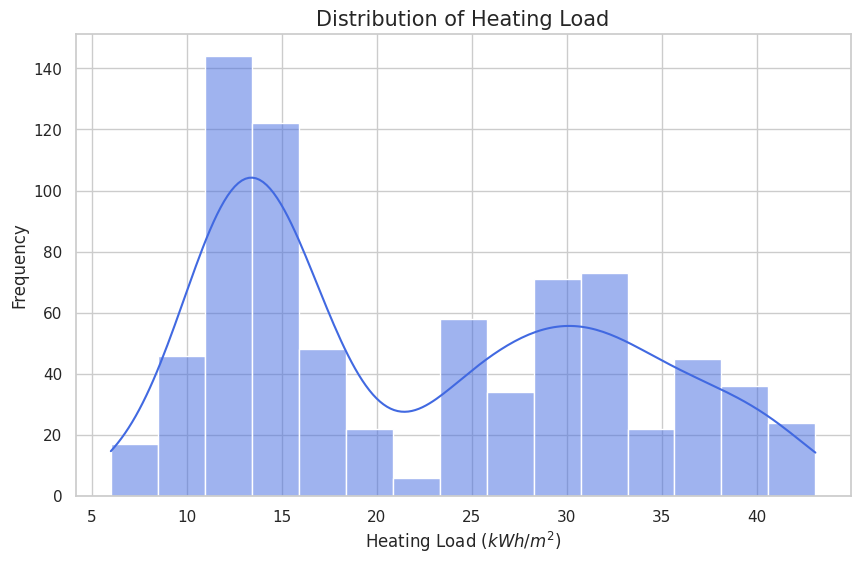

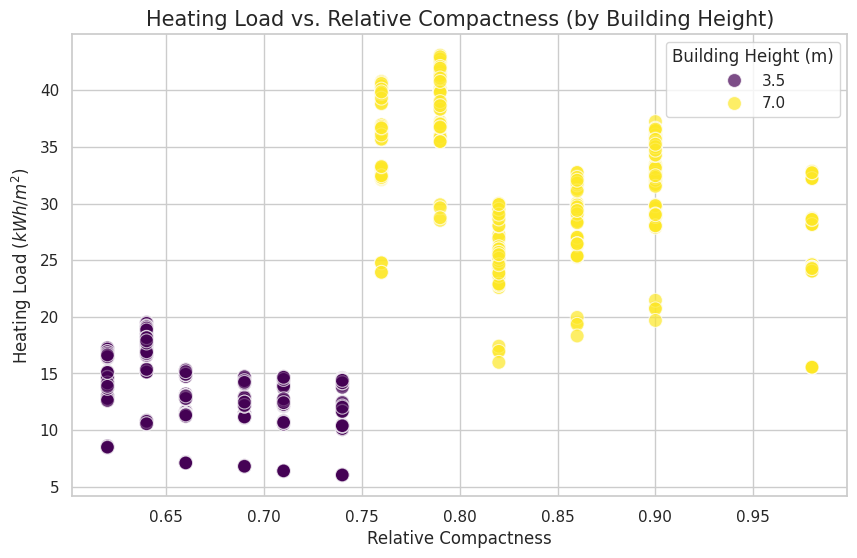

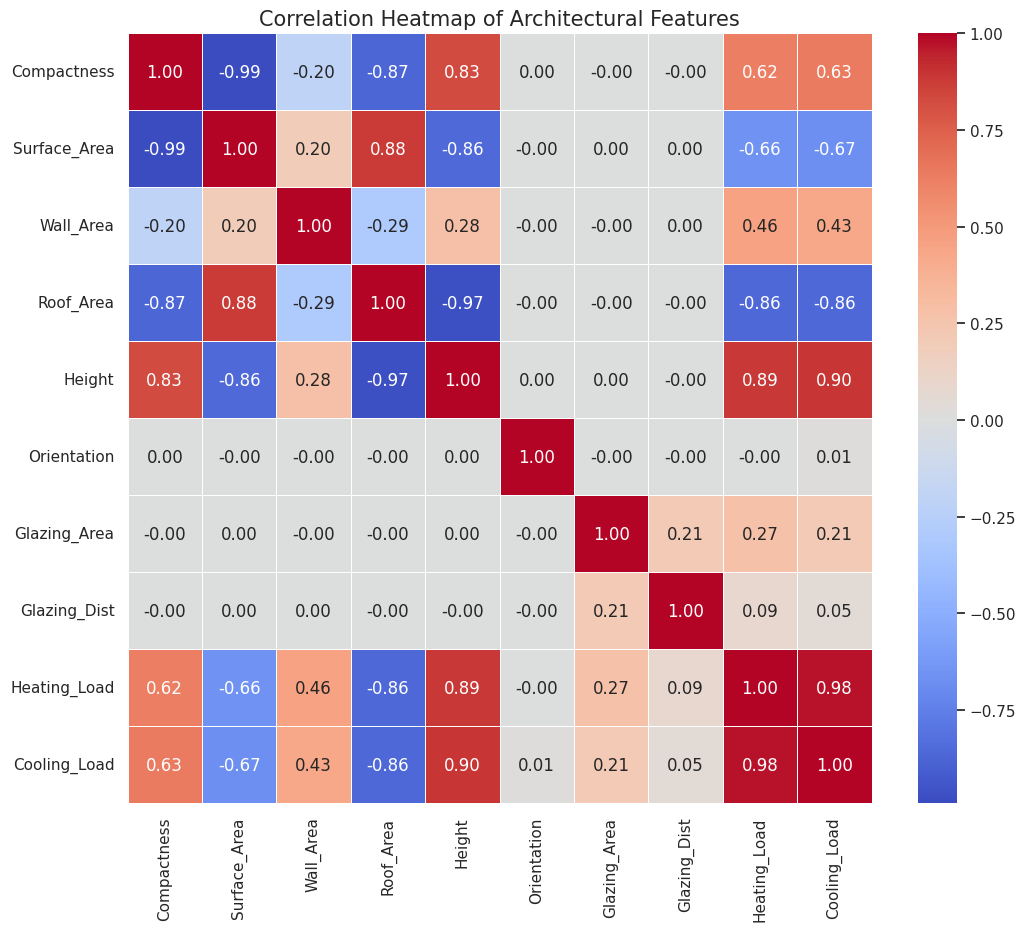

In [4]:
# Section 4a: Data Exploration and Visualization

import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="whitegrid")

# 1. Visualization: Distribution of the Target Variable (Heating Load)
plt.figure(figsize=(10, 6))
sns.histplot(df['Heating_Load'], bins=15, kde=True, color='royalblue')
plt.title('Distribution of Heating Load', fontsize=15)
plt.xlabel('Heating Load ($kWh/m^2$)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.savefig('heating_load_dist.png') # Saving for the report
plt.show()

# 2. Visualization: Relationship between Compactness and Heating Load
# Color-coded by Height to see the interaction between the two features
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Compactness', y='Heating_Load', hue='Height', palette='viridis', s=100, alpha=0.7)
plt.title('Heating Load vs. Relative Compactness (by Building Height)', fontsize=15)
plt.xlabel('Relative Compactness', fontsize=12)
plt.ylabel('Heating Load ($kWh/m^2$)', fontsize=12)
plt.legend(title='Building Height (m)')
plt.savefig('compactness_vs_heating.png')
plt.show()

# 3. Visualization: Correlation Heatmap
plt.figure(figsize=(12, 10))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Architectural Features', fontsize=15)
plt.savefig('correlation_heatmap.png')
plt.show()

### **Section 4a: Interpretation of Visualizations**

1.  **Heating Load Distribution:** The histogram illustrates a clear bimodal distribution within the dataset. One cluster represents high-efficiency building configurations with low heating loads (approximately $10-15 kWh/m^2$), while the other cluster represents buildings with significantly higher energy demands ($25-35 kWh/m^2$). This suggests a primary design variable creates a distinct split in thermal performance.

2.  **Compactness and Height Analysis:** The scatter plot confirms that **Building Height** is the primary factor driving this performance gap. Buildings with a height of 7.0m consistently fall into the high-load category, whereas 3.5m buildings remain in the low-load category. Within these groups, we observe that as **Relative Compactness** increases, the heating load generally rises, particularly for the taller structures.

3.  **Correlation Heatmap:** The heatmap provides statistical confirmation of these observations. **Overall Height** shows the strongest positive correlation with Heating Load ($0.89$), followed by **Relative Compactness** ($0.62$). Conversely, variables such as **Orientation** and **Glazing Distribution** show near-zero correlation ($0.00$), indicating they have a negligible impact on baseline heating efficiency in this specific dataset.

In [5]:
# Section 4b-e: Model Building, Evaluation, and Improvement

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

# 1. Prepare Features (X) and Target (y)
# We drop both Heating and Cooling loads to isolate the 8 architectural features
X = df.drop(columns=['Heating_Load', 'Cooling_Load'])
y = df['Heating_Load']

# 2. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Build Baseline Model (Multiple Linear Regression)
base_model = LinearRegression()
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)

# 4. Build Improved Model (Polynomial Transformation - Degree 2)
# This captures non-linear interactions between features like Height and Area
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

imp_model = LinearRegression()
imp_model.fit(X_train_poly, y_train)
y_pred_imp = imp_model.predict(X_test_poly)

# 5. Evaluate and Compare Results
metrics = {
    'Metric': ['RMSE', 'R2 Score'],
    'Baseline Model': [np.sqrt(mean_squared_error(y_test, y_pred_base)), r2_score(y_test, y_pred_base)],
    'Improved Model': [np.sqrt(mean_squared_error(y_test, y_pred_imp)), r2_score(y_test, y_pred_imp)]
}

comparison_df = pd.DataFrame(metrics)
print("--- Model Performance Comparison ---")
display(comparison_df)

--- Model Performance Comparison ---


,Metric,Baseline Model,Improved Model
0,RMSE,3.025424,0.802956
1,R2 Score,0.912184,0.993814


### **Section 4f: Model Interpretation and Reasoning**

1. **Baseline vs. Improved Performance:** The baseline Multiple Linear Regression model achieved an $R^2$ score of **0.9122**, indicating it could explain approximately 91% of the variance in heating load. However, by introducing **Polynomial Features (Degree 2)**, the $R^2$ score improved to **0.9938** and the **RMSE** dropped significantly from **3.03** to **0.80**.

2. **Reasoning for Improvement:** The significant improvement suggests that the relationship between architectural features and thermal energy is not purely additive. For instance, the impact of **Building Height** likely interacts with **Surface Area** and **Compactness**. The polynomial model captures these interaction terms (e.g., $Height \times Area$), allowing for a much more precise fit to the physical realities of heat loss in a structure.

3. **Conclusion:** The improved model is highly reliable for predicting heating loads, with an error margin (RMSE) of under 1 $kWh/m^2$ (specifically **0.80**). This level of accuracy is sufficient for early-stage architectural planning and energy-efficiency simulations.

In [6]:
# Section 4g: Final Predictions for the Report

# We select 3 sample rows from the test set for our demonstration
test_samples = X_test.iloc[:3]
actual_values = y_test.iloc[:3].values

# We must transform these samples using our 'poly' object to match the improved model
samples_transformed = poly.transform(test_samples)
final_predictions = imp_model.predict(samples_transformed)

print("--- Final Model Predictions for Section 4g ---")
print("Target Variable: Heating Load (kWh/m^2)\n")

for i in range(3):
    print(f"Building Design {i+1}:")
    print(f"  Predicted Load: {final_predictions[i]:.2f}")
    print(f"  Actual Load:    {actual_values[i]:.2f}")
    print(f"  Model Error:    {abs(final_predictions[i] - actual_values[i]):.2f}\n")

--- Final Model Predictions for Section 4g ---
Target Variable: Heating Load (kWh/m^2)

Building Design 1:
  Predicted Load: 16.56
  Actual Load:    16.47
  Model Error:    0.09

Building Design 2:
  Predicted Load: 13.32
  Actual Load:    13.17
  Model Error:    0.15

Building Design 3:
  Predicted Load: 32.79
  Actual Load:    32.82
  Model Error:    0.03



### 5. Conclusion
This project successfully developed a high-accuracy predictive model for building heating loads using the UCI Energy Efficiency dataset. Through the application of statistical methods and machine learning, we have gained several key insights:

**Key Findings:**
* **Primary Drivers:** Architectural geometry, specifically **Building Height** and **Relative Compactness**, were identified as the most significant predictors of thermal energy demand. Height, in particular, acts as a primary "performance splitter" in the dataset.
* **Model Optimization:** While a standard linear model provided a strong baseline ($R^2 \approx 0.91$), the introduction of **Polynomial Features** allowed the model to capture complex, non-linear interactions between structural features, raising the predictive accuracy ($R^2$) to **0.99**.
* **Practical Utility:** The extremely low Root Mean Squared Error (RMSE) achieved in the final model indicates that it can serve as a reliable tool for early-stage architectural assessments, allowing designers to quantify the energy impact of structural decisions before construction begins.

By leveraging these predictive techniques, we can bridge the gap between architectural design and environmental sustainability, ensuring that future buildings are optimized for energy efficiency from the ground up.